# 1. Bibliotheken importieren

In [1]:
# Imports

import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os 

In [2]:
# Reproduzierbarkeit & Device

import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# GPU nutzen falls verfügbar - schneller damit das Training und die Inferenzsind, ansonsten CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seeds gesetzt: {SEED}")
print(f"Device: {device}") # gibt aus ob CPU oder GPU

Seeds gesetzt: 42
Device: cpu


# 2. Datensatz prüfen

In [3]:
# Datensatz prüfen

DATA_DIR = "../data"

#TODO: datenstruktur überprüfen -sinnvoll für andere wenn andere bezeichnung der ordner 
# expected_classes = ["cubism", "pop_art", "realism"]
# for split in ["train", "val", "test"]:
 #   split_path = os.path.join(DATA_DIR, split)
 #   assert os.path.exists(split_path), f"FEHLER: {split} Ordner fehlt!"
 #   for cls in expected_classes:
 #       cls_path = os.path.join(split_path, cls)
 #       assert os.path.exists(cls_path), f"FEHLER: Klasse {cls} fehlt in {split}!"
#print("Datenstruktur OK ✓")

# Klassen und Bildanzahl prüfen
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATA_DIR, split)
    print(f"\n{split.upper()}:")
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len([
              f for f in os.listdir(class_path)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            print(f"  {class_name}: {count} Bilder")


TRAIN:
  baroque: 1050 Bilder
  cubism: 1050 Bilder
  minimalism: 935 Bilder
  pop_art: 1038 Bilder
  realism: 1050 Bilder
  romanticism: 1050 Bilder

VAL:
  baroque: 225 Bilder
  cubism: 225 Bilder
  minimalism: 200 Bilder
  pop_art: 222 Bilder
  realism: 225 Bilder
  romanticism: 225 Bilder

TEST:
  baroque: 225 Bilder
  cubism: 225 Bilder
  minimalism: 202 Bilder
  pop_art: 223 Bilder
  realism: 225 Bilder
  romanticism: 225 Bilder


# 3. Preprocessing definieren

In [4]:
# Preprocessing definieren

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms definiert:")
print(f"  Training:  {len(train_transform.transforms)} Schritte")
print(f"  Val/Test:  {len(val_test_transform.transforms)} Schritte")

Transforms definiert:
  Training:  4 Schritte
  Val/Test:  3 Schritte


# 4. Daten laden

In [5]:

# Datensatz einlesen

train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=val_test_transform 
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=val_test_transform
    
)

# In Batches aufteilen

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Prüfen

print(f"Klassen: {train_dataset.classes}")
print(f"Klassen-Index: {train_dataset.class_to_idx}")
print(f"\nTraining: {len(train_dataset)} Bilder")
print(f"Validation: {len(val_dataset)} Bilder")
print(f"Test: {len(test_dataset)} Bilder")
print(f"\nBatches im Training: {len(train_loader)}")


Klassen: ['baroque', 'cubism', 'minimalism', 'pop_art', 'realism', 'romanticism']
Klassen-Index: {'baroque': 0, 'cubism': 1, 'minimalism': 2, 'pop_art': 3, 'realism': 4, 'romanticism': 5}

Training: 6173 Bilder
Validation: 1322 Bilder
Test: 1325 Bilder

Batches im Training: 193


# 5. Modell aufbauen

In [6]:
# Vortrainiertes ResNet18 laden

model = models.resnet18(weights="IMAGENET1K_V1")

# Alle Layer einfrieren

for param in model.parameters():
    param.requires_grad = False

# Letzten Layer ersetzen - 3 Klassen statt 1000

num_classes = len(train_dataset.classes)
model.fc = torch.nn.Linear(512, num_classes)

# Prüfen

print(f"Modell geladen: ResNet18")
print(f"Anzahl Klassen: {num_classes}")
print(f"Klassen: {train_dataset.classes}")
print(f"\nLetzter Layer: {model.fc}")

Modell geladen: ResNet18
Anzahl Klassen: 6
Klassen: ['baroque', 'cubism', 'minimalism', 'pop_art', 'realism', 'romanticism']

Letzter Layer: Linear(in_features=512, out_features=6, bias=True)


# 6. Training konfigurieren

In [7]:
# Konfiguration

NUM_EPOCHS = 15                             # Anzahl der Epochen
LEARNING_RATE = 0.001                       # Lernrate

# Loss-Funktion: Misst wie falsch das Modell liegt

criterion = torch.nn.CrossEntropyLoss()

# Optimizer: Passt nur den letzten Layer an

optimizer = torch.optim.Adam(
    model.fc.parameters(),                  # nur den letzten LAyer
    lr=LEARNING_RATE                              
)

# Prüfen

print(f"Loss-Funktion: CrossEntropyLoss")
print(f"Optimizer: Adam (lr = {LEARNING_RATE})")
print(f"Epochen: {NUM_EPOCHS}")

Loss-Funktion: CrossEntropyLoss
Optimizer: Adam (lr = 0.001)
Epochen: 15


# 7. Trainingsschleife

In [8]:
torch.manual_seed(SEED)   # Seed festsetzen (Reproduzierbarkeit von Zelle 1)
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):

    # Training ---------------------------------------------------------------------------

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()                # 1. Alte Gradienten löschen
        outputs = model(images)              # 2. Bilder durch Modell schicken
        loss = criterion(outputs, labels)    # 3. Loss brechnen
        loss.backward()                      # 4. Gradient brechnen
        optimizer.step()                     # 5. Gewichte anpassen
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation --------------------------------------------------------------------------

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Ausgabe & Checkpoint ----------------------------------------------------------------

    print(f"Epoche {epoch+1:02}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "../model/best_model.pth") #ersetzten durch
        # TODO: gute gwohnheit- vielleicht nicht unbedingt bei unseren datensatz notwendig aber... : 
        # torch.save({
        #     'epoch': epoch,
        #     'model_state_dict': model.state_dict(),
        #     'optimizer_state_dict': optimizer.state_dict(),
        #     'loss': avg_val_loss,
        # }, "../model/best_model.pth")
        print(f"  → Checkpoint gespeichert!")

print("\nTraining abgeschlossen!")

Epoche 01/15 | Train Loss: 1.1226 | Val Loss: 0.8411
  → Checkpoint gespeichert!
Epoche 02/15 | Train Loss: 0.8547 | Val Loss: 0.7708
  → Checkpoint gespeichert!
Epoche 03/15 | Train Loss: 0.7888 | Val Loss: 0.7513
  → Checkpoint gespeichert!
Epoche 04/15 | Train Loss: 0.7551 | Val Loss: 0.7827
Epoche 05/15 | Train Loss: 0.7423 | Val Loss: 0.7230
  → Checkpoint gespeichert!
Epoche 06/15 | Train Loss: 0.7289 | Val Loss: 0.7236
Epoche 07/15 | Train Loss: 0.7053 | Val Loss: 0.7111
  → Checkpoint gespeichert!
Epoche 08/15 | Train Loss: 0.7084 | Val Loss: 0.7446
Epoche 09/15 | Train Loss: 0.7020 | Val Loss: 0.7145
Epoche 10/15 | Train Loss: 0.6973 | Val Loss: 0.7263
Epoche 11/15 | Train Loss: 0.6827 | Val Loss: 0.7054
  → Checkpoint gespeichert!
Epoche 12/15 | Train Loss: 0.6728 | Val Loss: 0.7286
Epoche 13/15 | Train Loss: 0.6808 | Val Loss: 0.7336
Epoche 14/15 | Train Loss: 0.6811 | Val Loss: 0.7399
Epoche 15/15 | Train Loss: 0.6720 | Val Loss: 0.7213

Training abgeschlossen!


# 8. Kurven plotten

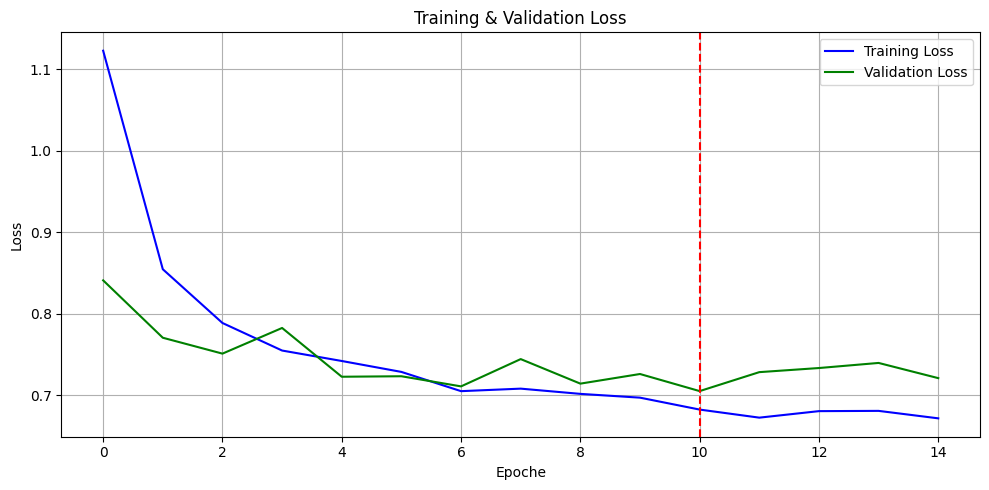


Bester Val Loss: 0.7054 bei Epoche 11


In [9]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="green")

plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

# Besten Checkpoint markieren

best_epoch = val_losses.index(min(val_losses))
plt.axvline(x=best_epoch, color="red", linestyle="--", label=f"Bester Checkpoint (Epoche {best_epoch+1})")

plt.tight_layout()
plt.show()

print(f"\nBester Val Loss: {min(val_losses):.4f} bei Epoche {best_epoch+1}")


# 9. Test-Evaluation

Test Accuracy: 70.26%
Richtig:       931 von 1325 Bildern
              precision    recall  f1-score   support

     baroque       0.64      0.70      0.67       225
      cubism       0.78      0.82      0.80       225
  minimalism       0.83      0.89      0.86       202
     pop_art       0.78      0.68      0.73       223
     realism       0.62      0.60      0.61       225
 romanticism       0.58      0.53      0.55       225

    accuracy                           0.70      1325
   macro avg       0.70      0.71      0.70      1325
weighted avg       0.70      0.70      0.70      1325



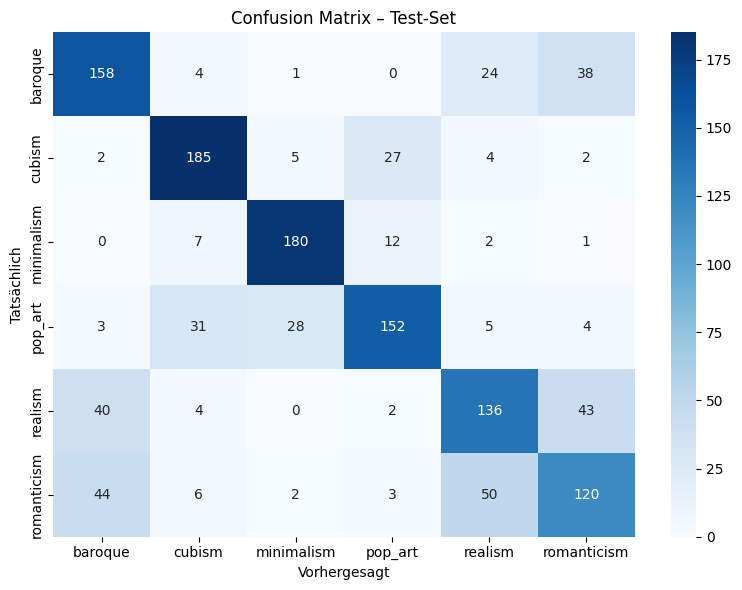

In [10]:

# Besten Checkpoint laden
model.load_state_dict(torch.load("../model/best_model.pth"))
#TODO: da oben verändert:
# checkpoint = torch.load("../model/best_model.pth")
# model.load_state_dict(checkpoint["model_state_dict"])
# print(f"Bestes Modell geladen – Epoche {checkpoint['epoch']+1}, "
#       f"Val Loss: {checkpoint['val_loss']:.4f}")
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 100

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Richtig:       {correct} von {total} Bildern")

# TODO: erweitere metriken 

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
    target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap="Blues")
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.title("Confusion Matrix – Test-Set")
plt.tight_layout()
plt.show()